## Mục tiêu

Phân tích đặc tính chuỗi thời gian của các tài sản đại diện nhằm:

* Quan sát xu hướng dài hạn
* Phát hiện tính mùa vụ
* Kiểm tra tính ổn định trước khi dự báo

## Import các thư viện cần thiết

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

## 1. Khởi tạo và Chuẩn bị dữ liệu đại diện

Để phân tích chuỗi thời gian một cách hiệu quả, chúng ta chọn ra **4 tài sản đại diện** cho **4 hành vi thị trường khác biệt**. Việc này giúp tập trung vào việc so sánh đặc tính của từng lớp tài sản mà không bị nhiễu bởi quá nhiều dữ liệu tương đồng.

* **BTC-USD**: Đại diện nhóm **Tiền điện tử** *(biến động cực cao, giao dịch 24/7)*.
* **AAPL**: Đại diện **Cổ phiếu tăng trưởng** *(chịu ảnh hưởng mạnh từ tin tức doanh nghiệp và kết quả kinh doanh)*.
* **^GSPC**: Đại diện **Chỉ số S&P 500** *(thước đo sức khỏe kinh tế vĩ mô và tâm lý thị trường)*.
* **GC=F**: Đại diện **Vàng** *(tài sản trú ẩn an toàn trong giai đoạn bất ổn)*.


In [24]:
file_path = max(
    Path("../data/snapshots").glob("market_snapshot_*.csv")
)
print("Latest snapshot:", file_path)
df = pd.read_csv(file_path)
df['datetime'] = pd.to_datetime(df['time_timestamp'], unit='s')
df = df.sort_values(['symbol', 'datetime'])
symbols = ["BTC-USD", "AAPL", "^GSPC", "GC=F"]
df_sub = df[df['symbol'].isin(symbols)].copy()
df_sub = df_sub.set_index('datetime')

print(f"Dữ liệu từ: {df_sub.index.min()} đến {df_sub.index.max()}")
df_sub.head()

Latest snapshot: ..\data\snapshots\market_snapshot_20260510_150719.csv
Dữ liệu từ: 2025-11-10 08:00:00 đến 2026-05-10 08:00:00


,symbol,timeframe,open,high,low,close,volume,time_timestamp
datetime,,,,,,,,
2025-11-10 14:30:00,AAPL,1h,268.950012,273.730011,268.950012,271.856995,7030981,1762785000
2025-11-10 15:30:00,AAPL,1h,271.829987,271.989990,269.049988,269.066406,3083676,1762788600
2025-11-10 16:30:00,AAPL,1h,269.040009,269.758789,268.489990,269.079987,2346213,1762792200
2025-11-10 17:30:00,AAPL,1h,269.070007,270.230011,269.010010,269.730011,1807442,1762795800
2025-11-10 18:30:00,AAPL,1h,269.709991,270.307709,267.454987,269.660004,3188667,1762799400


## 2. Phân tích Xu hướng dài hạn

- Phần này giúp quan sát xu hướng tổng thể của giá theo thời gian để xác định các giai đoạn **tăng (Uptrend)**, **giảm (Downtrend)** hoặc **đi ngang (Sideways)**.

- Do mức giá giữa các tài sản chênh lệch lớn *(BTC ~100k, AAPL ~200)*, ta sử dụng **biểu đồ con (Subplots)** để quan sát rõ đặc điểm biến động của từng mã.

### 2.1 Trực quan hóa giá đóng cửa

- Mục tiêu là theo dõi chuỗi **giá đóng cửa** để nhận diện xu hướng dài hạn và so sánh đặc điểm vận động giữa các nhóm tài sản.


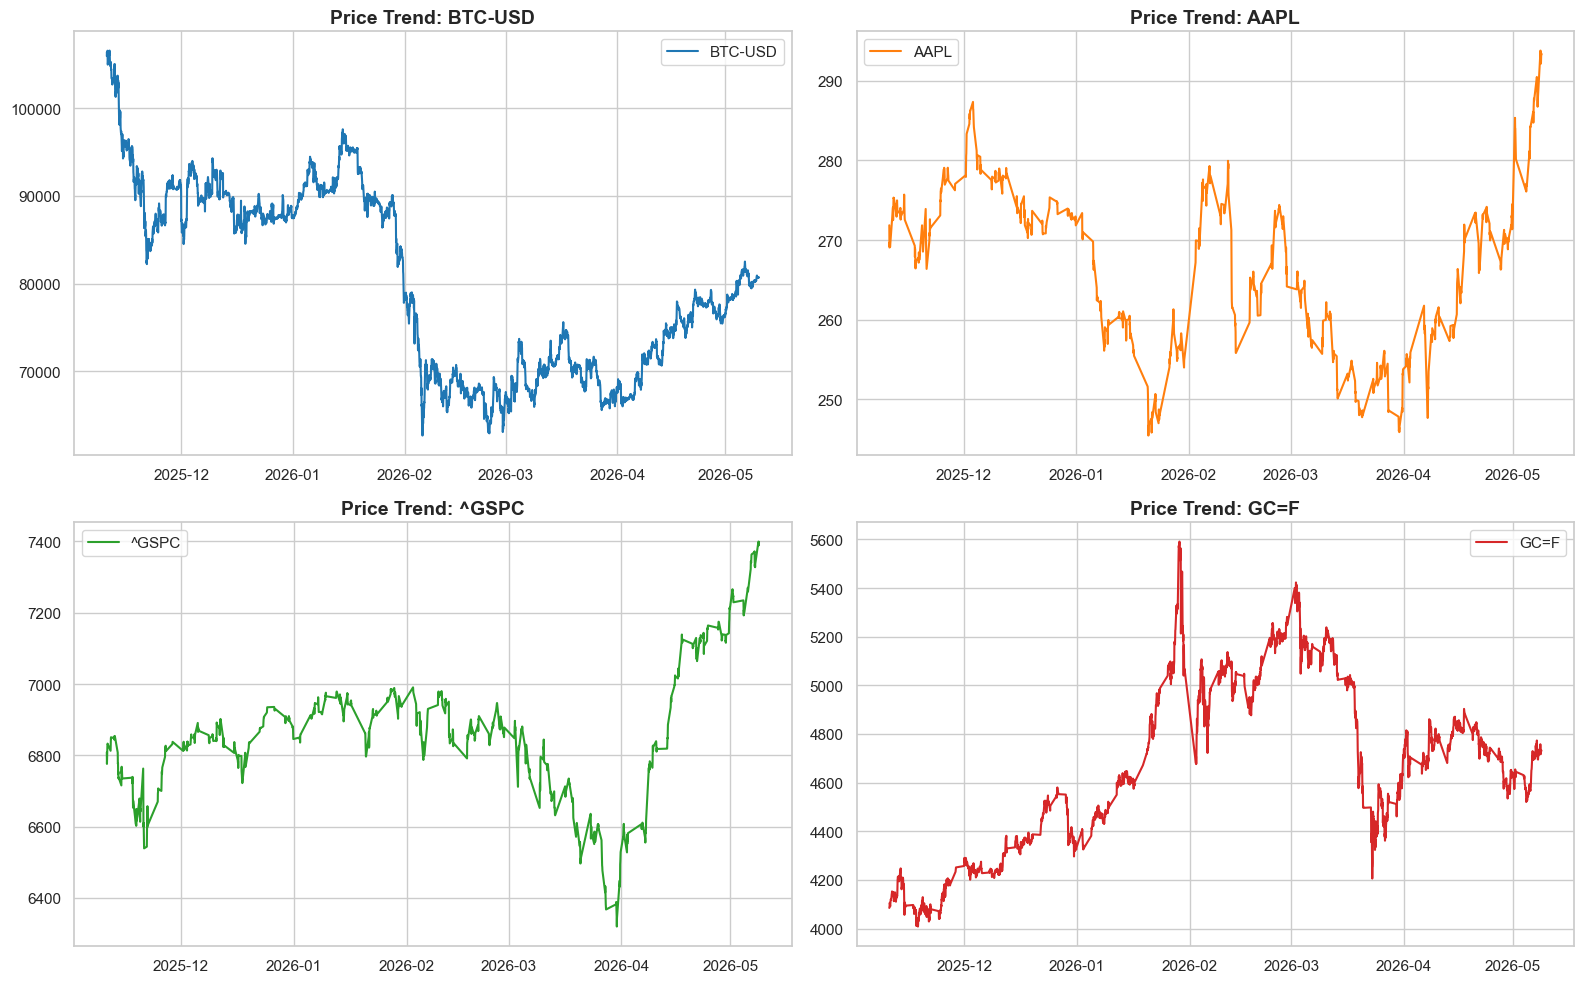

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

for i, sym in enumerate(symbols):
    data = df_sub[df_sub['symbol'] == sym]
    axes[i].plot(data['close'], label=sym, color=sns.color_palette("tab10")[i])
    axes[i].set_title(f"Price Trend: {sym}", fontsize=14, fontweight='bold')
    axes[i].legend()

plt.tight_layout()
plt.show()

#### **Nhận xét xu hướng dài hạn:**

Quan sát diễn biến giá của 4 tài sản từ cuối năm 2025 đến tháng 5/2026, có thể thấy dòng tiền trên thị trường có sự dịch chuyển khá rõ:

* **Sự đồng pha của Chứng khoán (Apple Inc. & S&P 500 Index):**
  AAPL và S&P 500 cho thấy mức tương quan rất cao trong toàn bộ giai đoạn quan sát. Điểm đáng chú ý nhất là nhịp giảm mạnh vào khoảng **tháng 4/2026**, sau đó cả hai nhanh chóng phục hồi theo mô hình **V-shaped recovery**, vượt các vùng đỉnh cũ và thiết lập mức cao mới vào tháng 5.

* **Bitcoin “hụt hơi” so với thị trường truyền thống:**
  Trong khi thị trường chứng khoán liên tục lập đỉnh mới, BTC lại trải qua đợt điều chỉnh mạnh từ vùng **trên 100.000 USD** xuống gần **60.000 USD** từ tháng 2/2026. Sau đó, giá phục hồi chậm và chủ yếu dao động đi ngang, chưa theo kịp đà tăng của thị trường chứng khoán trong tháng 5.

* **Gold Futures – Biến động mạnh của tài sản trú ẩn:**
  Giá vàng tăng mạnh vào đầu năm 2026, phản ánh nhu cầu tìm kiếm tài sản an toàn trong giai đoạn thị trường bất ổn. Tuy nhiên, khi dòng tiền quay trở lại nhóm cổ phiếu vào giai đoạn **tháng 4–5/2026**, vàng chịu áp lực bán mạnh và ghi nhận mức biến động lớn.

**Tổng thể, dòng tiền có xu hướng dịch chuyển từ tài sản phòng thủ sang tài sản tăng trưởng khi tâm lý thị trường dần cải thiện.**


### 2.2 Đường trung bình động

Đường trung bình động giúp **làm mượt dữ liệu giá**, từ đó xác định rõ hơn xu hướng thị trường.

Với dữ liệu khung **1 giờ**, sử dụng các mức MA sau:

* **MA24**: Trung bình 24 giờ *(≈ 1 ngày)*
* **MA72**: Trung bình 72 giờ *(≈ 3 ngày)*
* **MA168**: Trung bình 168 giờ *(≈ 1 tuần)*

Các đường MA này giúp phân biệt **xu hướng ngắn, trung và dài hạn** một cách trực quan hơn.


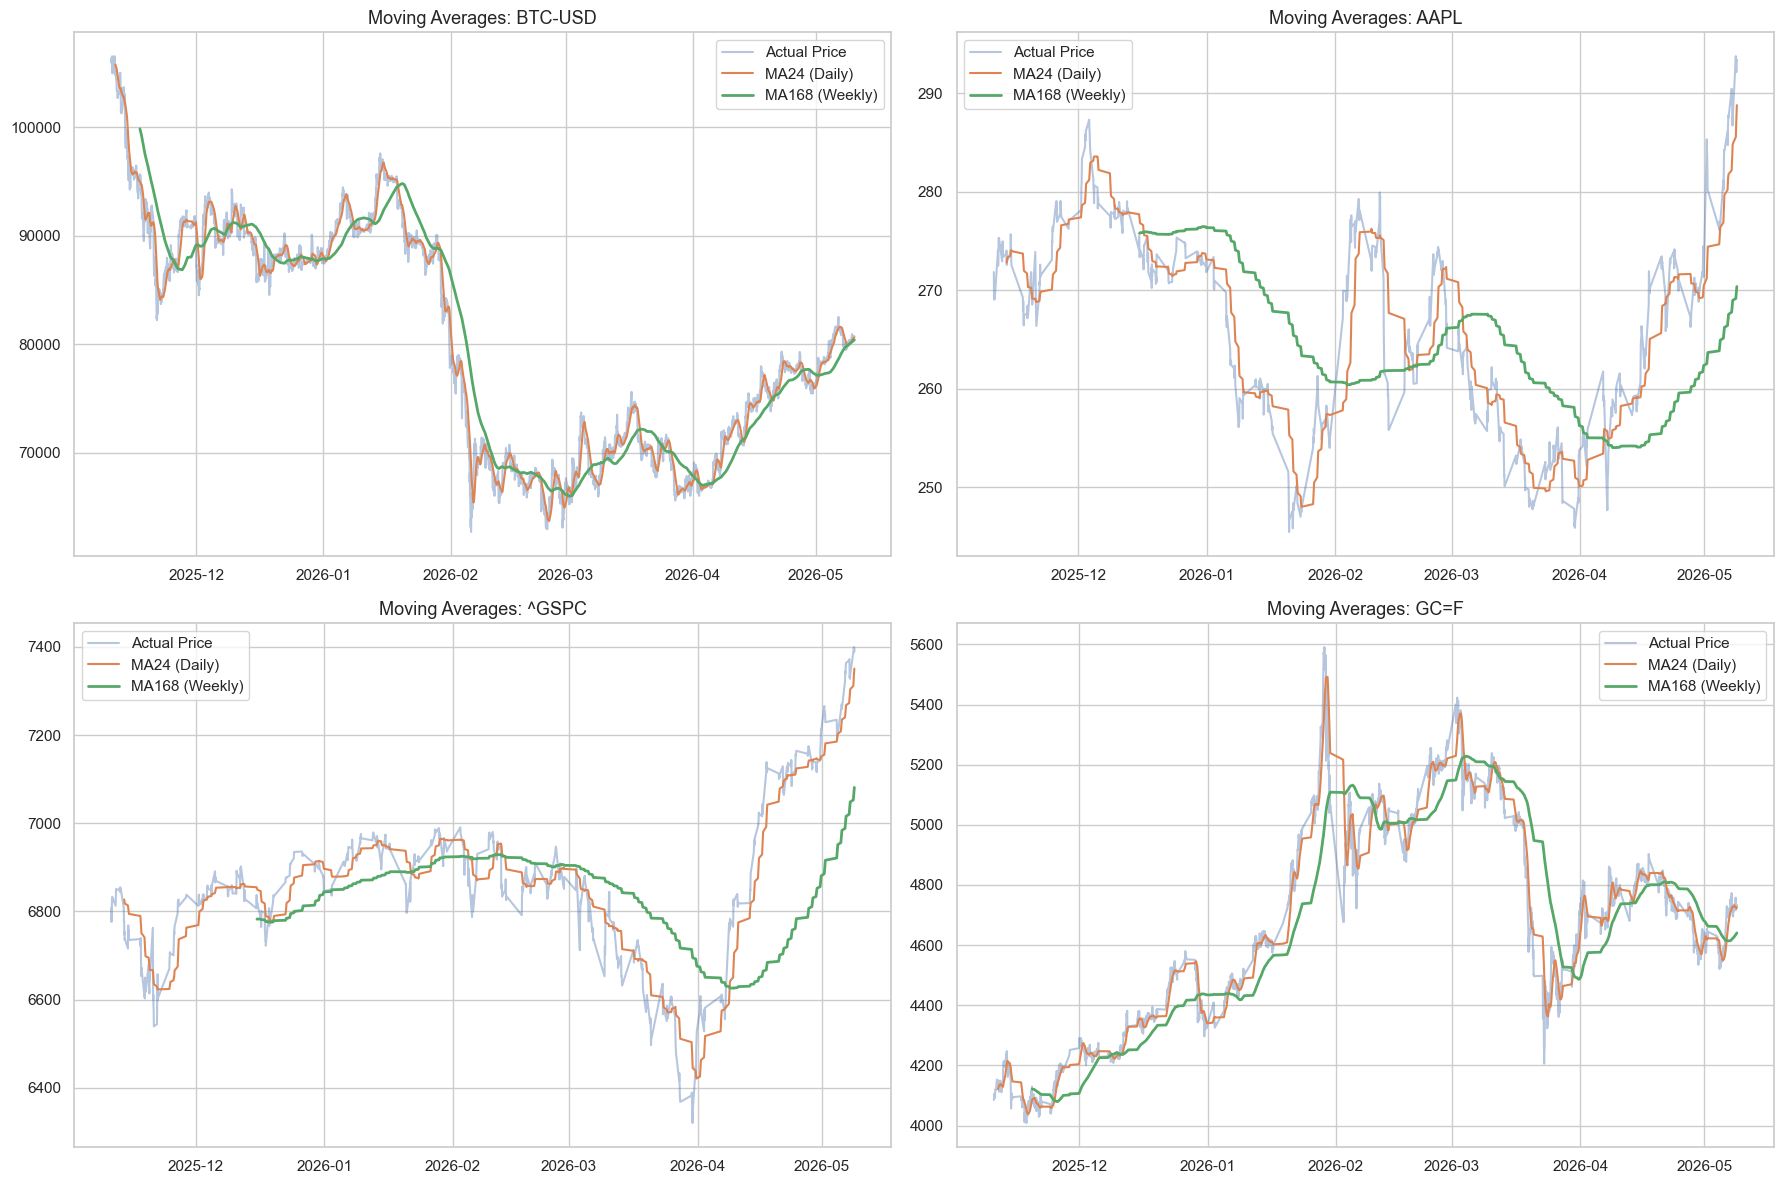

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, sym in enumerate(symbols):
    data = df_sub[df_sub['symbol'] == sym].copy()
    
    # Tính toán các đường MA
    data['MA24'] = data['close'].rolling(window=24).mean()
    data['MA168'] = data['close'].rolling(window=168).mean()
    
    axes[i].plot(data['close'], alpha=0.4, label='Actual Price')
    axes[i].plot(data['MA24'], label='MA24 (Daily)', linewidth=1.5)
    axes[i].plot(data['MA168'], label='MA168 (Weekly)', linewidth=2)
    
    axes[i].set_title(f"Moving Averages: {sym}", fontsize=13)
    axes[i].legend()

plt.tight_layout()
plt.show()

##### **Nhận xét phân tích đường trung bình động:**

Các đường trung bình động *(MA)* giúp giảm nhiễu và làm rõ xu hướng giá giữa các nhóm tài sản.

* **Chứng khoán (Apple Inc. & S&P 500 Index):**
  Trong tháng 5/2026, giá và đường **MA24** đều nằm cao hơn rõ rệt so với **MA168**, cho thấy đà tăng ngắn hạn rất mạnh. Tuy nhiên, khoảng cách lớn giữa các đường MA cũng cho thấy thị trường có thể đang ở trạng thái **quá mua *(overbought)***.

* **Gold Futures:**
  Sau giai đoạn tăng mạnh đầu năm, giá vàng đã phá xuống dưới **MA168** vào giữa tháng 4/2026 và hiện dao động quanh đường trung bình dài hạn. Điều này cho thấy xu hướng tăng trước đó đã suy yếu và thị trường đang bước vào giai đoạn điều chỉnh.

* **Bitcoin:**
  BTC hiện dao động sát **MA168**, trong khi các đường MA ngắn và dài hạn liên tục cắt nhau. Đây là dấu hiệu của trạng thái **tích lũy *(consolidation)***, khi xu hướng chưa thực sự rõ ràng.



## 3. Phân tích Biến động lăn
Độ lệch chuẩn lăn của **tỷ suất sinh lợi (Rolling Standard Deviation)** giúp đo lường mức độ biến động của thị trường theo thời gian, hay có thể hiểu là “nhiệt độ” của thị trường.

Khi **volatility tăng mạnh**, đó thường là dấu hiệu của:

* Giai đoạn thị trường **bất ổn**
* Xuất hiện **tin tức hoặc sự kiện lớn**
* Tâm lý nhà đầu tư **dao động mạnh**

Ngược lại, volatility thấp cho thấy thị trường đang trong trạng thái **ổn định hoặc tích lũy**.

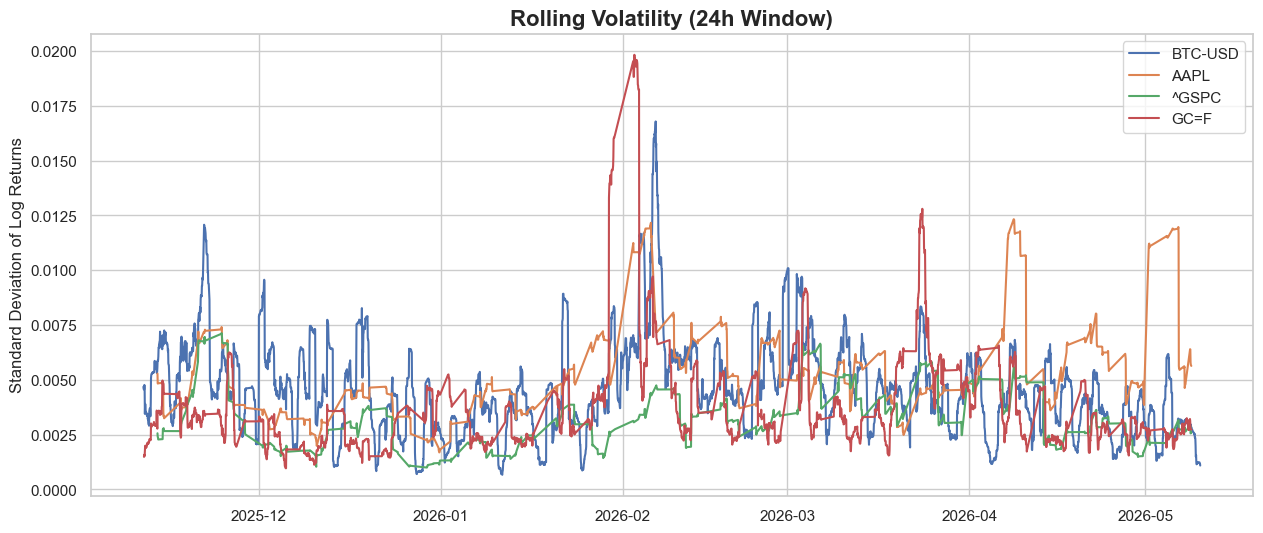

In [27]:
df_sub['log_return'] = np.log(df_sub['close'] / df_sub.groupby('symbol')['close'].shift(1))

# Vẽ biểu đồ Rolling Volatility
plt.figure(figsize=(15, 6))
for sym in symbols:
    data = df_sub[df_sub['symbol'] == sym]
    vol = data['log_return'].rolling(window=24).std() 
    plt.plot(vol, label=sym)

plt.title("Rolling Volatility (24h Window)", fontsize=16, fontweight='bold')
plt.ylabel("Standard Deviation of Log Returns")
plt.legend()
plt.show()

### **Nhận xét phân tích biến động lăn**

Biểu đồ **Rolling Volatility (24h)** cho thấy sự khác biệt rõ về mức độ rủi ro giữa các nhóm tài sản:

* **S&P 500 Index:**
  Đường biến động luôn duy trì ở mức thấp và khá ổn định trong toàn bộ giai đoạn quan sát, cho thấy đây là nhóm có **rủi ro hệ thống thấp nhất** nhờ hiệu ứng đa dạng hóa.

* **Bitcoin vs Apple Inc.:**

  * **BTC:** Biến động duy trì ở mức cao và xuất hiện liên tục, phản ánh trạng thái rủi ro thường trực của thị trường Crypto.
  * **AAPL:** Biến động theo từng cụm rõ rệt, có những giai đoạn tăng mạnh vào tháng 4–5/2026, thậm chí vượt BTC. Đây là đặc điểm thường thấy ở cổ phiếu khi xuất hiện các sự kiện quan trọng.

* **Gold Futures:**
  Vàng ghi nhận một đỉnh biến động rất mạnh vào đầu tháng 2/2026, cho thấy dù là tài sản trú ẩn, vàng vẫn có thể xuất hiện các **volatility shock** trong giai đoạn thị trường biến động mạnh.



## 4. Phân tích tính Mùa vụ

Phần này nhằm xác định liệu giá có **mẫu hình lặp lại theo thời gian** hay không, đặc biệt theo **giờ trong ngày** và **ngày trong tuần**. Đây là cơ sở quan trọng để xác định tham số **S (Seasonal)** trong mô hình **SARIMA**.

### 4.1 Biến động theo Giờ và Thứ

Sử dụng **Heatmap** để quan sát mức độ biến động của **lợi nhuận tuyệt đối**, từ đó xác định các “vùng nóng” của thị trường.

Mục tiêu chính:

* Nhận diện **khung giờ giao dịch sôi động nhất**
* Xác định **ngày trong tuần có biến động mạnh**
* Phát hiện các **mẫu hình mùa vụ lặp lại**
* Hỗ trợ xây dựng tham số mùa vụ cho mô hình dự báo (SARIMA)


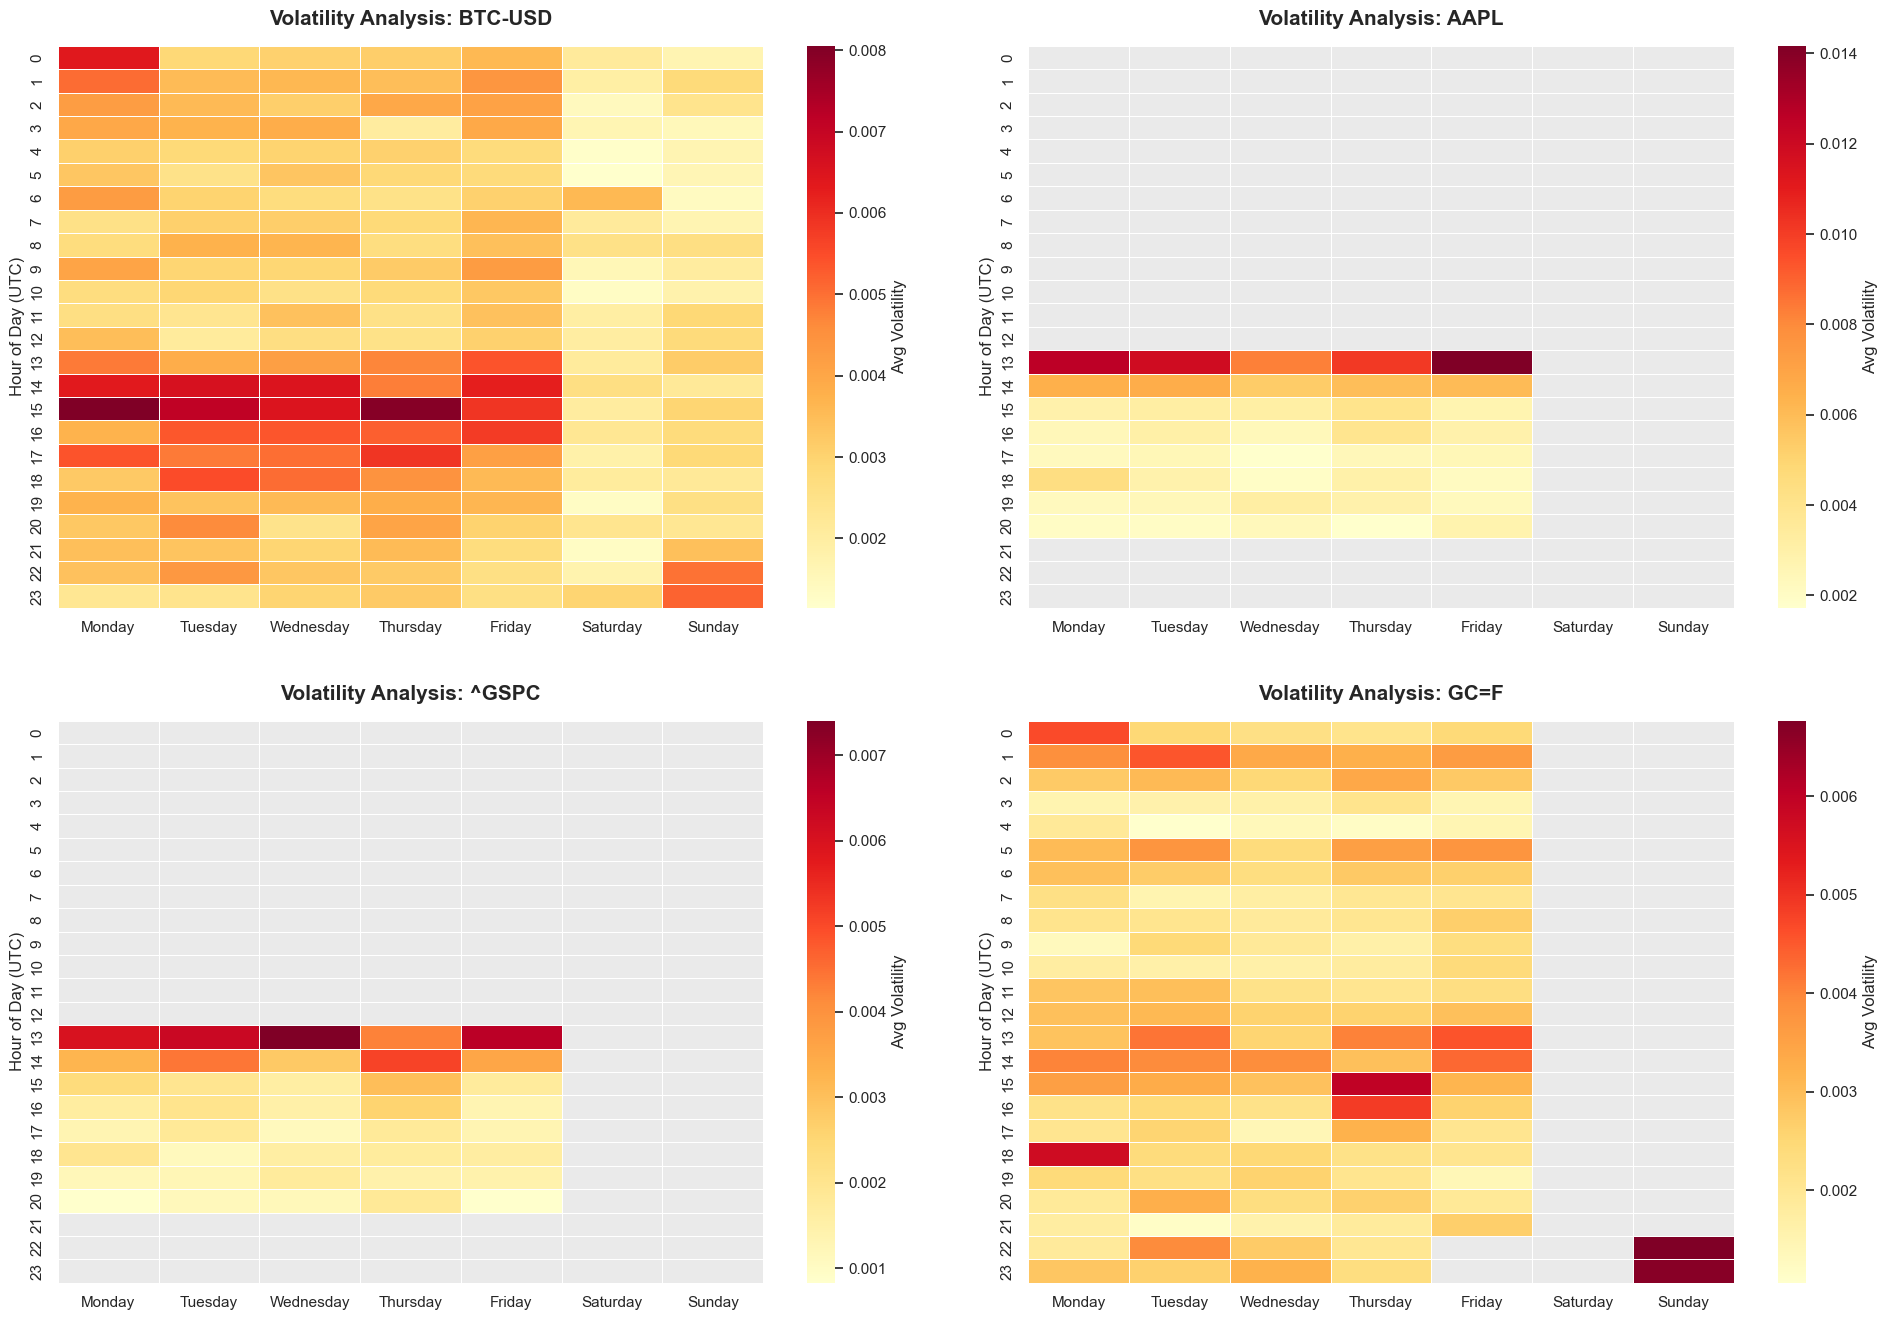

In [28]:
sns.set_theme(style="white")
df_sub['hour'] = df_sub.index.hour
df_sub['day_of_week'] = df_sub.index.day_name()
hours_24 = list(range(24))
days_7 = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for i, sym in enumerate(symbols):
    data = df_sub[df_sub['symbol'] == sym].copy()
    
    pivot = data.pivot_table(index='hour', columns='day_of_week', 
                             values='log_return', aggfunc=lambda x: np.mean(np.abs(x)))
    pivot = pivot.reindex(index=hours_24, columns=days_7)
    
    # 2. BÍ QUYẾT LÀM ĐẸP: Tô nền xám nhạt (#eaeaea) cho các vùng thị trường đóng cửa (NaN)
    axes[i].set_facecolor('#eaeaea')
    
    sns.heatmap(pivot, 
                cmap='YlOrRd', 
                ax=axes[i], 
                cbar_kws={'label': 'Avg Volatility'},
                linewidths=0.5,     
                linecolor='white',  
                square=False)
    
    axes[i].grid(False)
    
    axes[i].set_title(f"Volatility Analysis: {sym}", fontsize=15, fontweight='bold', pad=15)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Hour of Day (UTC)")

plt.tight_layout(pad=3.0)
plt.show()

sns.set_theme(style="whitegrid")

##### **Nhận xét phân tích mùa vụ**

Biểu đồ Heatmap cho thấy khá rõ sự khác biệt về nhịp giao dịch giữa các nhóm tài sản, đồng thời phản ánh thời điểm dòng tiền tập trung mạnh nhất trên thị trường:

* **Hiệu ứng phiên Mỹ (US Session Effect):**
  Dù là **Apple Inc.**, **S&P 500 Index**, **Gold Futures** hay **Bitcoin**, mức biến động đều tập trung mạnh vào khung **13:00–15:00 UTC** *(8:00–10:00 sáng New York)*. Điều này cho thấy dòng tiền từ thị trường Mỹ đóng vai trò quan trọng trong việc tạo thanh khoản và biến động toàn cầu.

* **Apple Inc. & S&P 500 Index – Quy luật mở cửa thị trường:**
  Biến động thường tăng mạnh ngay đầu phiên giao dịch *(13:00 UTC)* do các lệnh chờ được khớp, sau đó giảm dần về cuối phiên. Các khoảng trống cuối tuần cũng phản ánh đúng đặc điểm giao dịch theo giờ hành chính.

* **Bitcoin – Đặc tính 24/7:**
  BTC giao dịch liên tục và không có ngày nghỉ. Dù biến động mạnh nhất vẫn tập trung ở phiên Mỹ, thị trường vẫn duy trì các nhịp biến động ở nhiều khung giờ khác trong ngày.

* **Gold Futures – Nhịp giao dịch 24/5:**
  Vàng có mức biến động trải đều trong tuần, đồng thời xuất hiện hoạt động rõ hơn vào cuối ngày Chủ Nhật *(22:00–23:00 UTC)*, phản ánh phản ứng của thị trường với các thông tin vĩ mô trước khi bước sang tuần giao dịch mới.


## 5. Kiểm tra tính Dừng

Để xây dựng các mô hình dự báo chuỗi thời gian như **ARIMA/SARIMA**, dữ liệu đầu vào cần đảm bảo **tính dừng (Stationarity)** — tức là các đặc trưng thống kê như **trung bình và phương sai không thay đổi theo thời gian**.

Chúng ta sử dụng kiểm định **Augmented Dickey-Fuller (ADF Test)** để đánh giá tính dừng trên:

* Giá đóng cửa (Close)
* Tỷ suất sinh lợi (Log Return)

### Giả thuyết kiểm định:

* **H0**: Chuỗi thời gian **không dừng** (Non-stationary)
* **H1**: Chuỗi thời gian **dừng** (Stationary)

### Quy tắc kết luận:

* Nếu **p-value < 0.05** → bác bỏ H0 → chuỗi **dừng**
* Nếu **p-value ≥ 0.05** → chưa đủ bằng chứng bác bỏ H0 → chuỗi **không dừng**


In [29]:
def check_stationarity(series):
    result = adfuller(series.dropna())
    return result[1] 

results = []
for sym in symbols:
    data = df_sub[df_sub['symbol'] == sym]
    p_close = check_stationarity(data['close'])
    p_return = check_stationarity(data['log_return'])
    
    results.append({
        'Symbol': sym,
        'P-Value (Close)': round(p_close, 4),
        'P-Value (Log Return)': round(p_return, 10),
        'Stationary (Close)?': 'Yes' if p_close < 0.05 else 'No',
        'Stationary (Return)?': 'Yes' if p_return < 0.05 else 'No'
    })

df_adf = pd.DataFrame(results)
display(df_adf)

,Symbol,P-Value (Close),P-Value (Log Return),Stationary (Close)?,Stationary (Return)?
0,BTC-USD,0.1100,0.0,No,Yes
1,AAPL,0.5464,0.0,No,Yes
2,^GSPC,0.8962,0.0,No,Yes
3,GC=F,0.3036,0.0,No,Yes


#### **Nhận xét kết quả kiểm định tính dừng (ADF Stationarity Test)**

Kết quả kiểm định **Augmented Dickey-Fuller (ADF)** cho thấy một đặc điểm điển hình của chuỗi thời gian tài chính:

##### **1. Giá gốc (Close Price) là chuỗi không dừng *(Non-Stationary)***

* Quan sát cột **P-Value (Close)**, cả 4 tài sản đều có giá trị lớn hơn mức ý nghĩa **5%** *(p > 0.05)*.
* Điều này cho thấy **không đủ cơ sở bác bỏ giả thuyết $H_0$**, tức chuỗi giá gốc có chứa **unit root** và mang đặc điểm của quá trình **random walk**.
* Nói cách khác, giá tài sản chịu ảnh hưởng mạnh bởi xu hướng dài hạn và thay đổi theo thời gian.

##### **2. Tỷ suất sinh lợi (Log Return) là chuỗi dừng *(Stationary)***

* Ở cột **P-Value (Log Return)**, cả 4 tài sản đều có giá trị rất nhỏ *(p << 0.05)*.
* Kết quả này cho phép **bác bỏ giả thuyết $H_0$**, xác nhận chuỗi **Log Return** đã đạt tính dừng.
* Việc lấy logarit và sai phân bậc 1 đã loại bỏ xu hướng dài hạn, giúp chuỗi dao động ổn định hơn quanh giá trị trung bình.

---

### **Định hướng cho Modeling**

* **Mô hình thống kê (ARIMA):**

  * Nếu dự báo trên **giá gốc**, cần sử dụng sai phân bậc 1 *(d = 1)* → **ARIMA(p,1,q)**.
  * Nếu dự báo trực tiếp trên **Log Return**, có thể sử dụng **ARMA(p,q)** với *(d = 0)*.

* **Machine Learning / Deep Learning:**

  * Không nên sử dụng trực tiếp **Close Price** làm biến đầu vào do nguy cơ **hồi quy giả mạo *(spurious regression)***.
  * Thay vào đó, dữ liệu nên được chuyển sang dạng **Returns**, **Volatility** hoặc các biến đã được chuẩn hóa trước khi huấn luyện mô hình.



## 6. Phân tách chuỗi thời gian

Bước này nhằm **phân rã dữ liệu giá** thành các thành phần cốt lõi để hiểu rõ cấu trúc vận động của chuỗi thời gian:

* **Trend (Xu hướng):** Xu hướng dài hạn của tài sản
* **Seasonal (Mùa vụ):** Các chu kỳ lặp lại theo thời gian cố định
* **Resid (Nhiễu):** Các biến động ngẫu nhiên hoặc cú sốc thị trường

Trong phân tích này, chúng ta chọn **BTC-USD** làm đại diện và sử dụng chu kỳ **period = 24** (tương ứng mô hình lặp lại theo từng ngày trong dữ liệu khung giờ).

Do biên độ giá biến động mạnh theo thời gian, ta áp dụng mô hình **nhân (multiplicative)** để phản ánh đúng đặc tính tỷ lệ thay đổi của chuỗi dữ liệu.


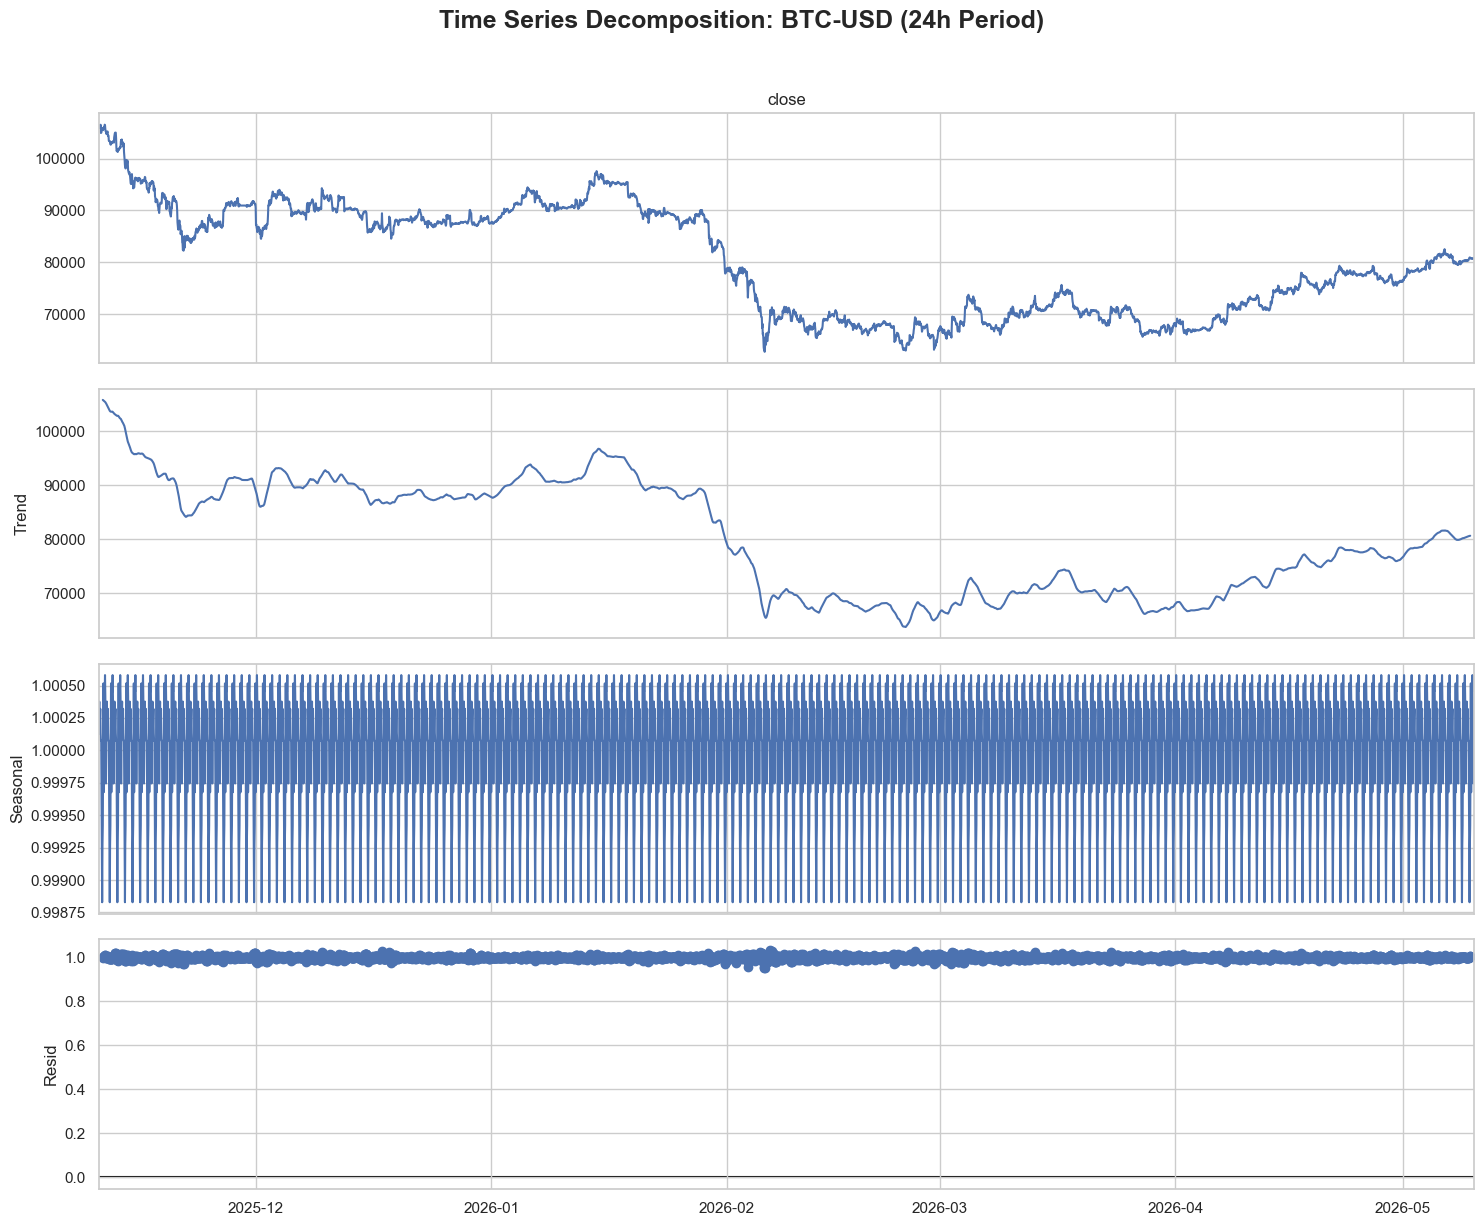

In [30]:
btc_data = df_sub[df_sub['symbol'] == 'BTC-USD']['close'].resample('1h').last().ffill()
btc_data = btc_data.dropna()
decomp = seasonal_decompose(btc_data, model='multiplicative', period=24)

sns.set_theme(style="whitegrid") 
fig = decomp.plot()
fig.set_size_inches(15, 12)

plt.suptitle('Time Series Decomposition: BTC-USD (24h Period)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Nhận xét phân tách chuỗi thời gian**

Kết quả phân tách chuỗi giá **Bitcoin** theo chu kỳ **24 giờ** cho thấy một số đặc điểm đáng chú ý:

* **Xu hướng (Trend) là thành phần chi phối:**
  Đường **Trend** bám khá sát chuỗi giá gốc và phản ánh rõ nhịp giảm mạnh vào đầu tháng 2/2026. Điều này cho thấy biến động giá BTC trong giai đoạn quan sát chủ yếu được dẫn dắt bởi xu hướng dòng tiền lớn hơn là các dao động ngắn hạn.

* **Tính mùa vụ (Seasonal) có tồn tại nhưng khá yếu:**
  Thành phần **Seasonal** dao động đều theo chu kỳ 24 giờ, phù hợp với kết quả phân tích phiên giao dịch trước đó. Tuy nhiên, biên độ dao động rất nhỏ *(xấp xỉ dưới 0.2%)*, cho thấy yếu tố thời gian trong ngày chỉ đóng góp một phần nhỏ vào biến động giá của BTC.

* **Phần dư (Residual) phản ánh mức độ nhiễu cao:**
  Thành phần **Residual** có độ phân tán lớn và mở rộng rõ hơn tại các giai đoạn biến động mạnh. Điều này cho thấy giá BTC chịu ảnh hưởng đáng kể từ các yếu tố ngẫu nhiên như tin tức thị trường, tâm lý nhà đầu tư và các cú sốc dòng tiền ngắn hạn.
